---
# STEP 8 생존 브랜드 분석

## 분석 개요

고압력(HP) 구간 내에서도 높은 별점을 유지하는 '생존 브랜드'와
낮은 별점을 보이는 '고전 브랜드'의 리뷰 텍스트를 비교하여
프랜차이즈 밀집 환경에서의 실질적인 차별화 전략을 도출한다.

| 단계 | 내용 |
|---|---|
| STEP 8-0 | 경쟁압력 구간별 생존율 및 평점 분포 — 입지 선정 가이드라인 |
| STEP 8-1 | 생존/고전 브랜드 그룹 정의 |
| STEP 8-2 | 그룹별 TF-IDF 키워드 차이 추출 |
| STEP 8-3 | 시각화 (바차트, 워드클라우드) |
| STEP 8-4 | 생존 브랜드 vs 프랜차이즈 키워드 비교 |
| STEP 8-5 | The Strip 제외 재분석 (상권 노이즈 통제) |
| STEP 8-6 | HP 구간 회귀분석 — 생존을 결정하는 단어 (OLS + HC3) |
| STEP 8-7 | STEP 06b 유의미 단어로 생존/고전 교차 검증(Mann-Whitney U) |
| STEP 8-8 | FPI 지도 시각화 — 창업자 입지 선정 도구 |

**그룹 정의**
- 생존 브랜드: HP 구간 + is_open=1 + 별점 4.0 이상 → 567개
- 고전 브랜드: HP 구간 + is_open=1 + 별점 3.0 이하 → 327개
- 중간(3.5점)은 분석에서 제외

**입력 데이터**
- `review_indie_cleaned.csv`: 전처리된 리뷰 텍스트
- `biz_indie_with_groups.csv`: FPI 구간 + 별점 정보
- `tfidf_brand.npz`: 브랜드별 TF-IDF 행렬 (STEP 7 저장)
- `terms_pca.npy`: 단어 목록 (STEP 7 저장)

## 공통 라이브러리 및 설정

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

fm._load_fontmanager(try_read_cache=False)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

PATH_to_data = "../results"
PATH_to_save = "../results"

print("라이브러리 로드 완료")

라이브러리 로드 완료


---
## STEP 8-0. 경쟁압력 구간별 입지 선정 가이드라인

본격적인 생존/고전 브랜드 분석에 앞서, FPI 구간별 전체 독립 브랜드의
생존율과 평점 분포를 파악하여 데이터 기반 입지 선정 가이드라인을 도출한다.

### 구간별 생존율 및 평점 분포

| 구간 | 전체 업체 | 생존율 | 고전율 | 생존/고전 비 | 평균 별점 | 평균 리뷰수 |
|---|---|---|---|---|---|---|
| NP (무풍지대) | 580개 | 61.0% | 17.9% | **3.41배** | 3.83 | 187개 |
| LP (저압력) | 1,217개 | 50.5% | 23.2% | **2.18배** | 3.69 | 247개 |
| HP (고압력) | 1,220개 | 46.5% | 26.8% | **1.74배** | 3.61 | 281개 |

경쟁압력이 높아질수록 생존/고전 비가 3.41 → 2.18 → 1.74로 일관되게 감소한다.
즉, 프랜차이즈 밀집도가 높을수록 독립 브랜드가 생존하기 어려워진다는 것이
데이터로 명확하게 확인된다.

**주목할 점**: HP 구간에서도 생존율이 46.5%로, 절반에 가까운 독립 브랜드가
고압력 환경에서도 생존한다. 이는 차별화 전략이 실제로 작동하고 있음을 시사하며,
STEP 8-1 이후 분석에서 그 전략을 구체적으로 도출한다.

**평균 리뷰수**는 NP(187개) < LP(247개) < HP(281개)로 HP에서 가장 많다.
고압력 상권일수록 유동인구가 많아 리뷰가 더 많이 쌓이는 구조다.

---

### 데이터 기반 입지 선정 가이드라인

| 구간 | 리스크 | 기회 요인 | 추천 창업 전략 |
|---|---|---|---|
| NP (무풍지대) | 낮음 | 틈새시장 선점 | 에스닉 전문점, 카페, 특색 음식 전문점 |
| LP (저압력) | 중간 | 적정 경쟁 환경 | 정통 외국 요리, 스시/라멘/스테이크 전문점 |
| HP (고압력) | 높음 | 높은 유동인구 | 음식 품질 + 서비스 경험 강화 필수 |

> **창업자 의사결정 프레임워크**:
> - 리스크 최소화 전략 → NP/LP 상권 선택 + 에스닉·정통 요리 전문점
> - 고수익 추구 전략 → HP 상권 진입 + 음식 품질·서비스 차별화 철저히 준비
> - 어떤 구간을 선택하든 생존 키워드(amaz, delici, favorit)를 마케팅 메시지에 반영하고
>   고전 위험 요소(bad, minut, manag)를 사전에 차단해야 한다.

In [36]:
# FPI 구간별 생존율 및 평점 분포 계산
indie_open = indie_groups[indie_groups['is_open'] == 1].copy()

guide = []
for group in ['NP', 'LP', 'HP']:
    df = indie_open[indie_open['fpi_group'] == group]
    total = len(df)
    survive = (df['stars'] >= 4.0).sum()
    struggle = (df['stars'] <= 3.0).sum()
    guide.append({
        'FPI 구간': group,
        '전체 업체': total,
        '생존(4.0↑)': survive,
        '생존율(%)': round(survive / total * 100, 1),
        '고전(3.0↓)': struggle,
        '고전율(%)': round(struggle / total * 100, 1),
        '평균 별점': round(df['stars'].mean(), 2),
        '중앙값 별점': df['stars'].median(),
        '평균 리뷰수': round(df['review_count'].mean(), 0),
    })

guide_df = pd.DataFrame(guide)
print("=== FPI 구간별 생존율 및 평점 분포 ===")
print(guide_df.to_string(index=False))

=== FPI 구간별 생존율 및 평점 분포 ===
FPI 구간  전체 업체  생존(4.0↑)  생존율(%)  고전(3.0↓)  고전율(%)  평균 별점  중앙값 별점  평균 리뷰수
    NP    580       354    61.0       104    17.9   3.83     4.0   187.0
    LP   1217       615    50.5       282    23.2   3.69     4.0   247.0
    HP   1220       567    46.5       327    26.8   3.61     3.5   281.0


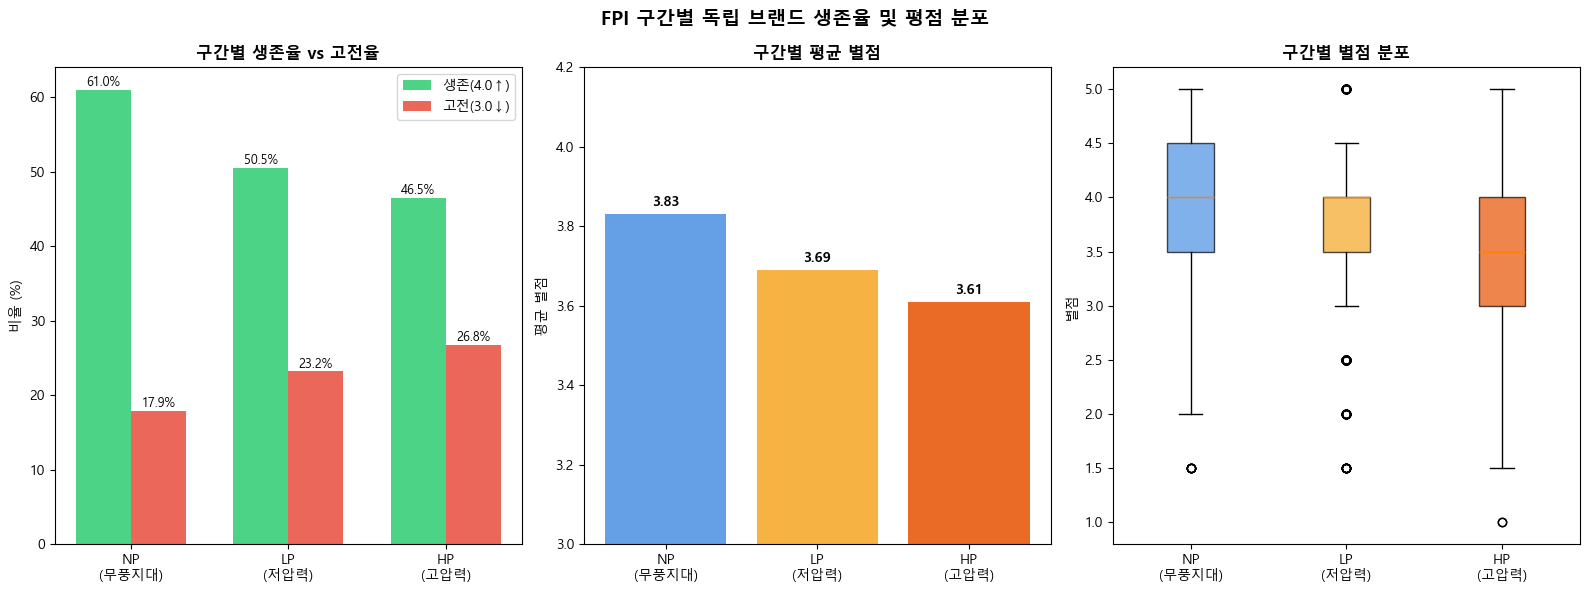

저장 완료: step8_location_guide.png


In [37]:
# 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('FPI 구간별 독립 브랜드 생존율 및 평점 분포',
             fontsize=14, fontweight='bold')

colors = ['#4a90e2', '#f5a623', '#e65100']
groups = ['NP', 'LP', 'HP']
group_labels = ['NP\n(무풍지대)', 'LP\n(저압력)', 'HP\n(고압력)']

# 1. 생존율 바차트
survival_rates = [guide_df[guide_df['FPI 구간']==g]['생존율(%)'].values[0] for g in groups]
struggle_rates = [guide_df[guide_df['FPI 구간']==g]['고전율(%)'].values[0] for g in groups]

x = np.arange(len(groups))
width = 0.35
axes[0].bar(x - width/2, survival_rates, width, label='생존(4.0↑)',
            color='#2ecc71', alpha=0.85)
axes[0].bar(x + width/2, struggle_rates, width, label='고전(3.0↓)',
            color='#e74c3c', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(group_labels)
axes[0].set_ylabel('비율 (%)')
axes[0].set_title('구간별 생존율 vs 고전율', fontweight='bold')
axes[0].legend()
for i, (s, g) in enumerate(zip(survival_rates, struggle_rates)):
    axes[0].text(i - width/2, s + 0.5, f'{s}%', ha='center', fontsize=9)
    axes[0].text(i + width/2, g + 0.5, f'{g}%', ha='center', fontsize=9)

# 2. 평균 별점 바차트
avg_stars = [guide_df[guide_df['FPI 구간']==g]['평균 별점'].values[0] for g in groups]
bars = axes[1].bar(group_labels, avg_stars, color=colors, alpha=0.85)
axes[1].set_ylabel('평균 별점')
axes[1].set_title('구간별 평균 별점', fontweight='bold')
axes[1].set_ylim(3.0, 4.2)
for bar, val in zip(bars, avg_stars):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f'{val}', ha='center', fontweight='bold')

# 3. 별점 박스플롯
data_by_group = [
    indie_open[indie_open['fpi_group'] == g]['stars'].values
    for g in groups
]
bp = axes[2].boxplot(data_by_group, labels=group_labels,
                     patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_ylabel('별점')
axes[2].set_title('구간별 별점 분포', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step8_location_guide.png", dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: step8_location_guide.png")

In [38]:
# 생존 가능성 지수 계산 (생존율 / 고전율)
print("=== 경쟁압력 구간별 입지 선정 가이드라인 ===\n")

for _, row in guide_df.iterrows():
    ratio = row['생존율(%)'] / row['고전율(%)']
    if row['FPI 구간'] == 'NP':
        strategy = "에스닉 전문점, 카페, 특색 음식 전문점"
        risk = "낮음"
        opportunity = "틈새시장 선점 가능"
    elif row['FPI 구간'] == 'LP':
        strategy = "정통 외국 요리, 스시/라멘/스테이크 전문점"
        risk = "중간"
        opportunity = "적정 경쟁 환경"
    else:
        strategy = "음식 품질 + 서비스 경험 강화 필수"
        risk = "높음"
        opportunity = "높은 유동인구, 단 차별화 필수"

    print(f"[{row['FPI 구간']}] {['무풍지대','저압력','고압력'][['NP','LP','HP'].index(row['FPI 구간'])]}")
    print(f"  전체 업체    : {row['전체 업체']:,}개")
    print(f"  생존율       : {row['생존율(%)']}% ({row['생존(4.0↑)']:,}개)")
    print(f"  고전율       : {row['고전율(%)']}% ({row['고전(3.0↓)']:,}개)")
    print(f"  생존/고전 비 : {ratio:.2f}배")
    print(f"  평균 별점    : {row['평균 별점']}")
    print(f"  평균 리뷰수  : {row['평균 리뷰수']:.0f}개")
    print(f"  리스크       : {risk}")
    print(f"  추천 전략    : {strategy}")
    print(f"  기회 요인    : {opportunity}")
    print()

=== 경쟁압력 구간별 입지 선정 가이드라인 ===

[NP] 무풍지대
  전체 업체    : 580개
  생존율       : 61.0% (354개)
  고전율       : 17.9% (104개)
  생존/고전 비 : 3.41배
  평균 별점    : 3.83
  평균 리뷰수  : 187개
  리스크       : 낮음
  추천 전략    : 에스닉 전문점, 카페, 특색 음식 전문점
  기회 요인    : 틈새시장 선점 가능

[LP] 저압력
  전체 업체    : 1,217개
  생존율       : 50.5% (615개)
  고전율       : 23.2% (282개)
  생존/고전 비 : 2.18배
  평균 별점    : 3.69
  평균 리뷰수  : 247개
  리스크       : 중간
  추천 전략    : 정통 외국 요리, 스시/라멘/스테이크 전문점
  기회 요인    : 적정 경쟁 환경

[HP] 고압력
  전체 업체    : 1,220개
  생존율       : 46.5% (567개)
  고전율       : 26.8% (327개)
  생존/고전 비 : 1.74배
  평균 별점    : 3.61
  평균 리뷰수  : 281개
  리스크       : 높음
  추천 전략    : 음식 품질 + 서비스 경험 강화 필수
  기회 요인    : 높은 유동인구, 단 차별화 필수



---
## STEP 8-1. 생존/고전 브랜드 그룹 정의

In [7]:
# 데이터 로드
review_cleaned = pd.read_csv(f"{PATH_to_data}/review_indie_cleaned.csv")
indie_groups   = pd.read_csv(f"{PATH_to_data}/biz_indie_with_groups.csv")

# ★ 영업 중인 HP 구간만 필터링 (이 부분이 빠졌던 거야)
hp_biz = indie_groups[
    (indie_groups['fpi_group'] == 'HP') &
    (indie_groups['is_open'] == 1)
].copy()

# 생존/고전 브랜드 분류
survivor = hp_biz[hp_biz['stars'] >= 4.0].copy()
struggle = hp_biz[hp_biz['stars'] <= 3.0].copy()

survivor['survival_group'] = '생존'
struggle['survival_group'] = '고전'

hp_labeled = pd.concat([survivor, struggle], ignore_index=True)

print(f"생존 브랜드: {len(survivor):,}개 (별점 4.0 이상)")
print(f"고전 브랜드: {len(struggle):,}개 (별점 3.0 이하)")
print(f"\n생존 브랜드 평균 별점: {survivor['stars'].mean():.2f}")
print(f"고전 브랜드 평균 별점: {struggle['stars'].mean():.2f}")
print(f"\n생존 브랜드 평균 리뷰수: {survivor['review_count'].mean():.0f}개")
print(f"고전 브랜드 평균 리뷰수: {struggle['review_count'].mean():.0f}개")

생존 브랜드: 567개 (별점 4.0 이상)
고전 브랜드: 327개 (별점 3.0 이하)

생존 브랜드 평균 별점: 4.21
고전 브랜드 평균 별점: 2.66

생존 브랜드 평균 리뷰수: 370개
고전 브랜드 평균 리뷰수: 161개


---
## STEP 8-2. 그룹별 TF-IDF 키워드 차이 추출

생존/고전 브랜드 각각의 리뷰를 합쳐서 TF-IDF 차이로
각 그룹에서 고유하게 나타나는 키워드를 추출한다.

> **주의**: 2개 문서(생존/고전)를 대상으로 TF-IDF를 계산하므로
> IDF 효과가 제한적이다. 결과는 탐색적 수준으로 해석하며,
> 통계적 검증은 STEP 8-6 회귀분석에서 수행한다.

In [8]:
# 리뷰에 생존/고전 그룹 태깅
review_hp = review_cleaned.merge(
    hp_labeled[['business_id', 'survival_group', 'stars']],
    on='business_id', how='inner'
)

print(f"생존 브랜드 리뷰: {(review_hp['survival_group']=='생존').sum():,}개")
print(f"고전 브랜드 리뷰: {(review_hp['survival_group']=='고전').sum():,}개")

생존 브랜드 리뷰: 209,686개
고전 브랜드 리뷰: 52,514개


In [9]:
# 그룹별 텍스트 합치기
survivor_text = ' '.join(
    review_hp[review_hp['survival_group'] == '생존']['text_clean'].dropna()
)
struggle_text = ' '.join(
    review_hp[review_hp['survival_group'] == '고전']['text_clean'].dropna()
)

# TF-IDF 계산 (2개 문서)
corpus_8 = [survivor_text, struggle_text]
vectorizer_8 = TfidfVectorizer(max_features=5000, min_df=1, max_df=1.0)
tfidf_8 = vectorizer_8.fit_transform(corpus_8)
terms_8 = vectorizer_8.get_feature_names_out()

tfidf_8_df = pd.DataFrame(
    tfidf_8.toarray(),
    index=['생존', '고전'],
    columns=terms_8
)

print(f"TF-IDF 행렬: {tfidf_8_df.shape}")

TF-IDF 행렬: (2, 5000)


In [10]:
# valid_words 필터 적용 후 TF-IDF 차이 계산
all_text_8 = (survivor_text + ' ' + struggle_text).split()
word_freq_8 = pd.Series(all_text_8).value_counts()

valid_words_8 = set(
    word for word, cnt in word_freq_8.items()
    if cnt >= 100
    and word.isalpha()
    and len(word) >= 3
)

print(f"유효 단어 수 (100회 이상): {len(valid_words_8):,}개")

# 생존 브랜드 고유 키워드 (생존 - 고전)
survivor_diff = (tfidf_8_df.loc['생존'] - tfidf_8_df.loc['고전'])\
                .sort_values(ascending=False)
survivor_diff = survivor_diff[survivor_diff.index.isin(valid_words_8)]

# 고전 브랜드 고유 키워드 (고전 - 생존)
struggle_diff = (tfidf_8_df.loc['고전'] - tfidf_8_df.loc['생존'])\
                .sort_values(ascending=False)
struggle_diff = struggle_diff[struggle_diff.index.isin(valid_words_8)]

print("\n=== 생존 브랜드 고유 키워드 상위 20개 ===")
print(survivor_diff.head(20).round(4).to_string())
print("\n=== 고전 브랜드 고유 키워드 상위 20개 ===")
print(struggle_diff.head(20).round(4).to_string())

유효 단어 수 (100회 이상): 5,495개

=== 생존 브랜드 고유 키워드 상위 20개 ===
great        0.0751
delici       0.0728
amaz         0.0582
menu         0.0540
love         0.0524
tri          0.0484
dish         0.0477
restaur      0.0461
burger       0.0432
flavor       0.0421
best         0.0417
steak        0.0411
sauc         0.0395
sushi        0.0373
perfect      0.0366
definit      0.0336
bread        0.0335
recommend    0.0309
excel        0.0279
fresh        0.0267

=== 고전 브랜드 고유 키워드 상위 20개 ===
buffet       0.1444
room         0.1009
stay         0.0661
hotel        0.0654
drink        0.0590
club         0.0548
like         0.0429
mgm          0.0422
line         0.0409
peopl        0.0403
bad          0.0387
bar          0.0371
floor        0.0344
danc         0.0331
night        0.0315
walk         0.0311
casino       0.0279
pay          0.0269
pretti       0.0267
breakfast    0.0253


---
## STEP 8-3. 시각화 (바차트, 워드클라우드)

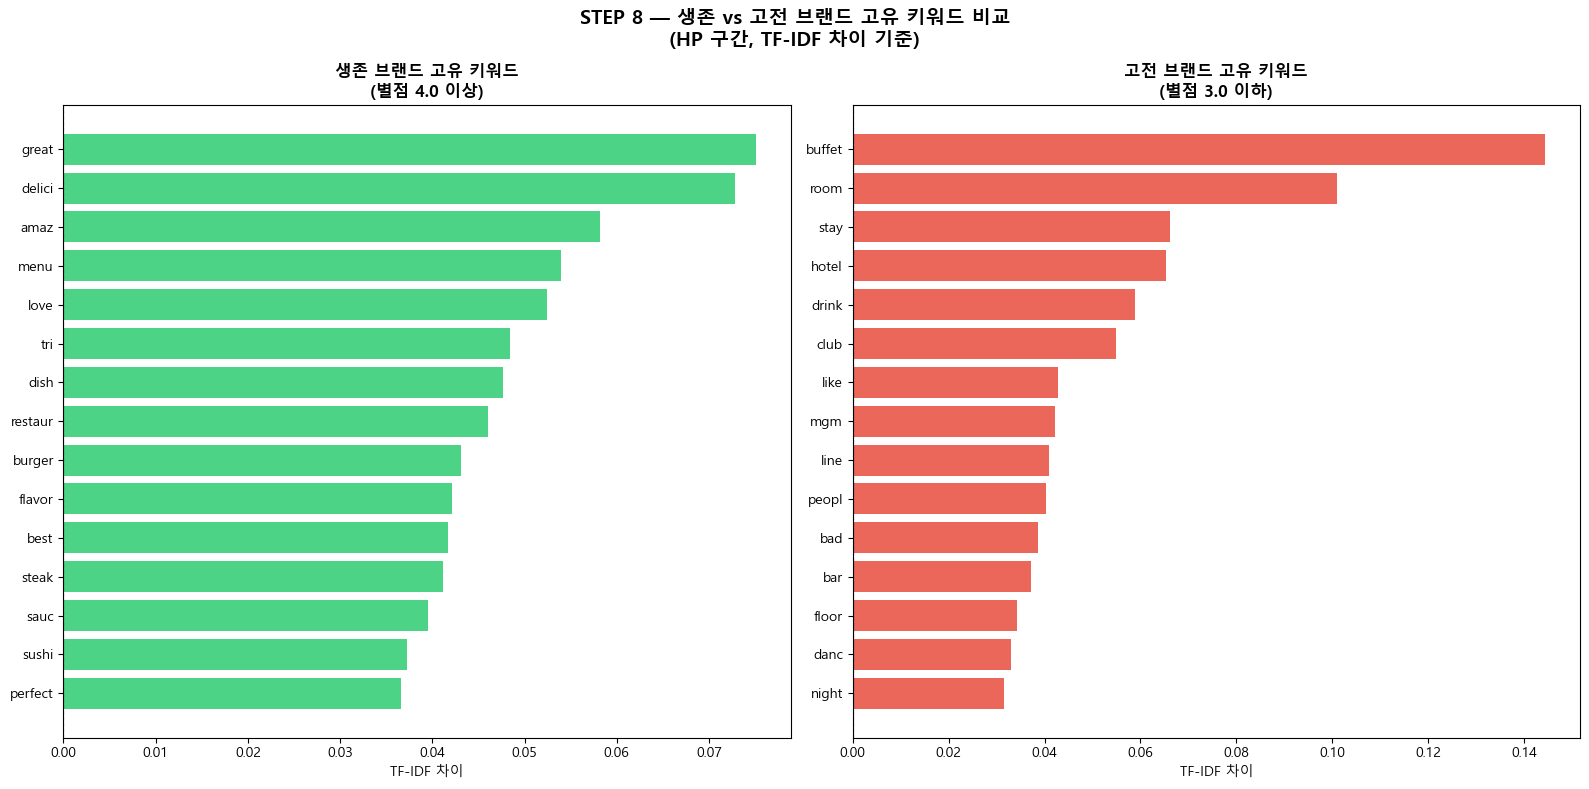

저장 완료: step8_survival_keywords.png


In [11]:
# 바차트 — 생존 vs 고전 고유 키워드
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('STEP 8 — 생존 vs 고전 브랜드 고유 키워드 비교\n(HP 구간, TF-IDF 차이 기준)',
             fontsize=14, fontweight='bold')

# 생존 브랜드
top_s = survivor_diff.head(15)
axes[0].barh(top_s.index[::-1], top_s.values[::-1],
             color='#2ecc71', alpha=0.85)
axes[0].set_title('생존 브랜드 고유 키워드\n(별점 4.0 이상)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('TF-IDF 차이')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=0.8)

# 고전 브랜드
top_str = struggle_diff.head(15)
axes[1].barh(top_str.index[::-1], top_str.values[::-1],
             color='#e74c3c', alpha=0.85)
axes[1].set_title('고전 브랜드 고유 키워드\n(별점 3.0 이하)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('TF-IDF 차이')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step8_survival_keywords.png", dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: step8_survival_keywords.png")

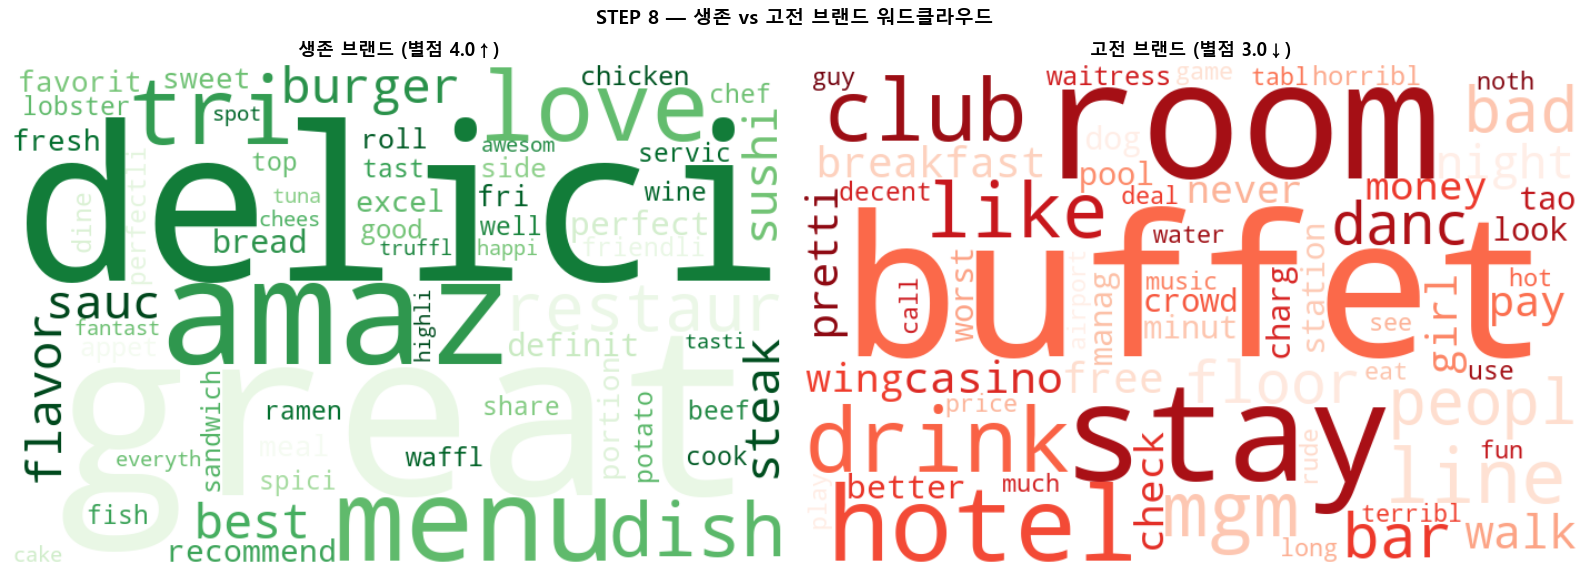

저장 완료: step8_survival_wordcloud.png


In [12]:
# 워드클라우드
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('STEP 8 — 생존 vs 고전 브랜드 워드클라우드',
             fontsize=14, fontweight='bold')

for ax, diff, title, cmap in zip(
    axes,
    [survivor_diff, struggle_diff],
    ['생존 브랜드 (별점 4.0↑)', '고전 브랜드 (별점 3.0↓)'],
    ['Greens', 'Reds']
):
    freq_dict = {w: s for w, s in diff.head(80).items() if s > 0}
    if freq_dict:
        wc = WordCloud(
            width=700, height=450,
            background_color='white',
            colormap=cmap,
            max_words=60
        ).generate_from_frequencies(freq_dict)
        ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step8_survival_wordcloud.png", dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: step8_survival_wordcloud.png")

---
## STEP 8-4. 프랜차이즈 키워드와 비교

생존 브랜드가 프랜차이즈와 어떤 점에서 언어적으로 차별화되는지 확인한다.

In [13]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english')) | {"does", "not", "thing"}

MANUAL_STOPWORDS = {
    'al', 'also', 'alway', 'anoth', 'area', 'around', 'ask',
    'back', 'bite', 'box',
    'come', 'could', 'came',
    'dont', 'day', 'de', 'didnt',
    'even', 'ever', 'el',
    'get', 'give', 'got',
    'im', 'ive',
    'let', 'la', 'last',
    'make', 'made', 'mayb',
    'name', 'one', 'round',
    'someth', 'still', 'seem', 'sinc', 'sub', 'said',
    'told', 'that', 'think', 'two', 'though', 'thought', 'took',
    'us', 'want', 'way', 'went', 'would', 'wasnt',
    'your', 'year', 'restaurant', 'place', 'food', 'get',
    'go', 'came', 'got', 'time', 'back', 'order', 'ordered',
}

stemmer = PorterStemmer()

def preprocess(text):
    if pd.isna(text):
        return ''
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [stemmer.stem(w) for w in tokens]
    tokens = [w for w in tokens if w not in MANUAL_STOPWORDS and len(w) > 2]
    return ' '.join(tokens)

print("preprocess 함수 정의 완료")

preprocess 함수 정의 완료


In [14]:
# biz_target에서 프랜차이즈 업체 가져오기
biz_target = pd.read_csv(f"{PATH_to_data}/biz_target.csv")
print(biz_target['is_franchise'].value_counts())

franchise_ids = biz_target[biz_target['is_franchise'] == True]['business_id']
print(f"\n프랜차이즈 업체 수: {len(franchise_ids)}개")

review_all = pd.read_csv(f"{PATH_to_data}/review_target.csv")
review_franchise_raw = review_all[review_all['business_id'].isin(franchise_ids)].copy()
print(f"프랜차이즈 리뷰 수: {len(review_franchise_raw):,}개")

is_franchise
False    4818
True     1081
Name: count, dtype: int64

프랜차이즈 업체 수: 1081개
프랜차이즈 리뷰 수: 45,532개


In [15]:
# 전처리 적용
print("프랜차이즈 리뷰 전처리 중... (시간 소요)")
review_franchise_raw['text_clean'] = review_franchise_raw['text'].apply(preprocess)
review_franchise = review_franchise_raw
print(f"전처리 완료: {len(review_franchise):,}개")

# 생존 브랜드 vs 프랜차이즈 TF-IDF 차이
franchise_text = ' '.join(review_franchise['text_clean'].dropna())

corpus_fc = [survivor_text, franchise_text]
vectorizer_fc = TfidfVectorizer(max_features=5000, min_df=1, max_df=1.0)
tfidf_fc = vectorizer_fc.fit_transform(corpus_fc)
terms_fc = vectorizer_fc.get_feature_names_out()

tfidf_fc_df = pd.DataFrame(
    tfidf_fc.toarray(),
    index=['생존브랜드', '프랜차이즈'],
    columns=terms_fc
)

# 유효 단어 필터
all_text_fc = (survivor_text + ' ' + franchise_text).split()
word_freq_fc = pd.Series(all_text_fc).value_counts()
valid_words_fc = set(
    w for w, c in word_freq_fc.items()
    if c >= 100 and w.isalpha() and len(w) >= 3
)

# 차이 계산
vs_franchise = (tfidf_fc_df.loc['생존브랜드'] - tfidf_fc_df.loc['프랜차이즈'])\
               .sort_values(ascending=False)
vs_franchise = vs_franchise[vs_franchise.index.isin(valid_words_fc)]

print("\n=== 생존 브랜드 vs 프랜차이즈 차별화 키워드 상위 20개 ===")
print(vs_franchise.head(20).round(4).to_string())
print("\n=== 프랜차이즈 고유 키워드 상위 20개 ===")
print(vs_franchise.tail(20).sort_values().round(4).to_string())

프랜차이즈 리뷰 전처리 중... (시간 소요)
전처리 완료: 45,532개

=== 생존 브랜드 vs 프랜차이즈 차별화 키워드 상위 20개 ===
great        0.0968
vega         0.0791
good         0.0770
restaur      0.0759
dish         0.0707
delici       0.0681
amaz         0.0628
sushi        0.0596
tri          0.0593
flavor       0.0544
definit      0.0514
best         0.0505
dessert      0.0494
dinner       0.0482
menu         0.0467
recommend    0.0460
steak        0.0442
buffet       0.0407
crab         0.0357
perfect      0.0337

=== 프랜차이즈 고유 키워드 상위 20개 ===
locat      -0.1667
custom     -0.0830
fast       -0.0794
sandwich   -0.0784
burger     -0.0763
drive      -0.0724
manag      -0.0658
employe    -0.0637
never      -0.0606
pizza      -0.0590
minut      -0.0589
work       -0.0584
chicken    -0.0453
thru       -0.0452
fri        -0.0444
call       -0.0412
burrito    -0.0402
wait       -0.0396
clean      -0.0379
know       -0.0376


**핵심 인사이트:**

>생존 브랜드는 "음식 그 자체" 로 소비자와 소통한다 (dish, flavor, delici, steak, sushi).
프랜차이즈는 "시스템과 운영" 으로 소비자와 소통한다 (fast, location, drive-thru, employee).
고압력 환경에서 살아남는 독립 브랜드의 차별화 전략은 표준화된 운영이 아닌 음식 품질과 다이닝 경험에 있다.

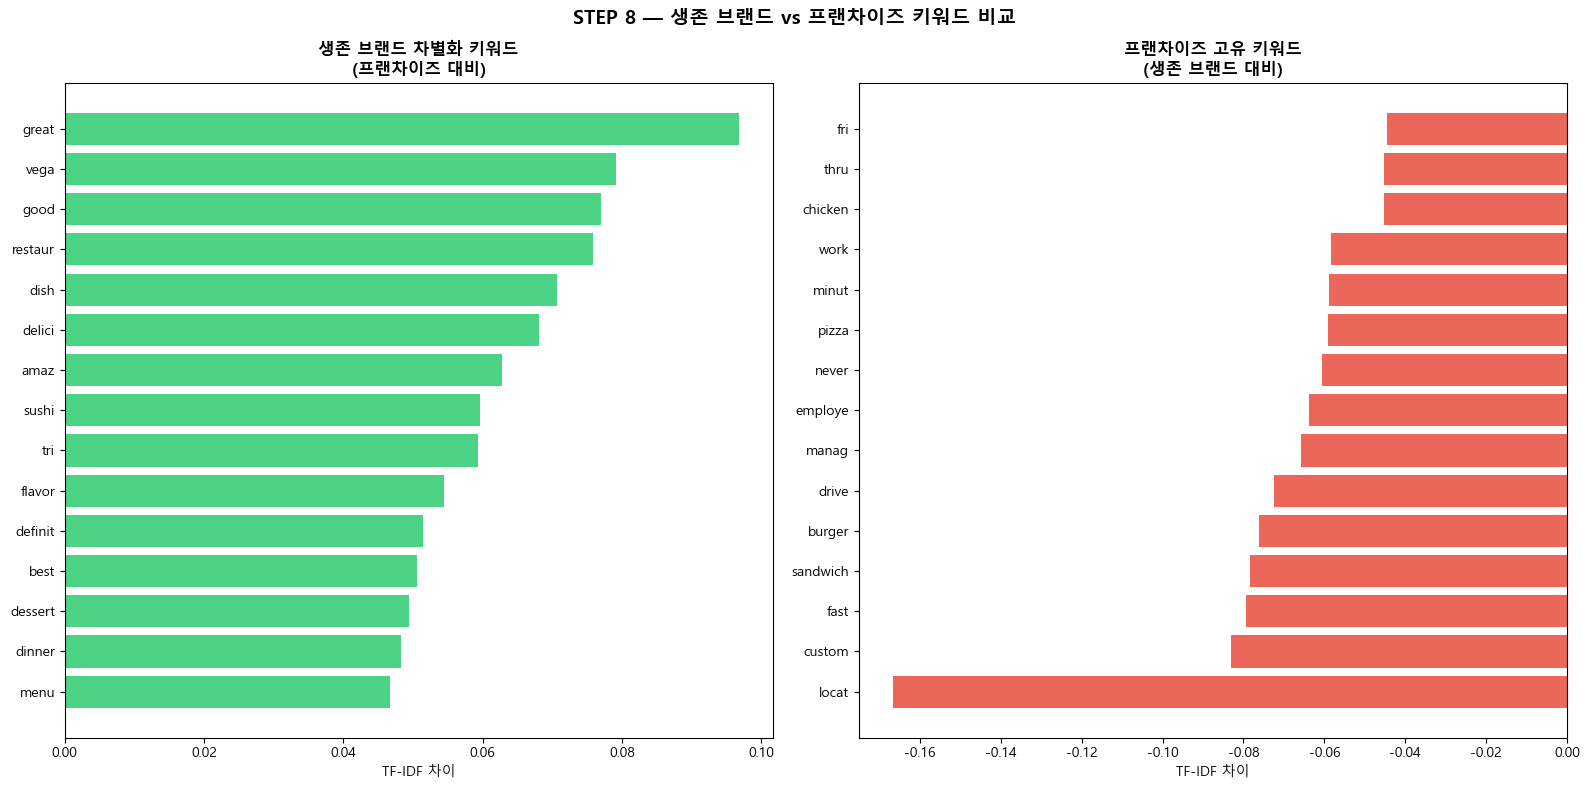

저장 완료: step8_vs_franchise.png


In [16]:
# 생존 브랜드 vs 프랜차이즈 바차트
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('STEP 8 — 생존 브랜드 vs 프랜차이즈 키워드 비교',
             fontsize=14, fontweight='bold')

# 생존 브랜드 차별화 키워드
top_sv = vs_franchise.head(15)
axes[0].barh(top_sv.index[::-1], top_sv.values[::-1],
             color='#2ecc71', alpha=0.85)
axes[0].set_title('생존 브랜드 차별화 키워드\n(프랜차이즈 대비)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('TF-IDF 차이')

# 프랜차이즈 고유 키워드
top_fc = vs_franchise.tail(15).sort_values()
axes[1].barh(top_fc.index, top_fc.values,
             color='#e74c3c', alpha=0.85)
axes[1].set_title('프랜차이즈 고유 키워드\n(생존 브랜드 대비)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('TF-IDF 차이')

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step8_vs_franchise.png", dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: step8_vs_franchise.png")

---
## STEP 8-5. The Strip 제외 재분석 (상권 노이즈 통제)

초기 분석에서 고전 브랜드 키워드로 hotel, casino, buffet, mgm 등
카지노·호텔 부속 시설 관련 단어가 상위에 등장하였다.
고전 브랜드 중 The Strip 소재 업체 비율(37.6%)이
생존 브랜드(24.3%)보다 13.3%p 높아 상권 특성이 결과를 왜곡할 가능성이 있다.

The Strip 상권을 제외하고 재분석하여 상권 환경 노이즈를 통제한다.

| 구분 | 전체 | The Strip 제외 |
|---|---|---|
| 생존 브랜드 | 567개 (24.3% Strip) | 429개 |
| 고전 브랜드 | 327개 (37.6% Strip) | 204개 |

**두 가지 인사이트를 모두 가져간다:**
1. Strip 포함: 카지노/호텔 부속 시설로 인식되는 독립 레스토랑은 낮은 별점을 받는다
2. Strip 제외: 상권 노이즈 제거 후 서비스 품질 실패(bad, slow, rude)가 고전의 핵심 원인으로 드러난다

**분석 대상 선정 및 보정**
>초기 분석에서 고전 브랜드(별점 3.0 이하)의 고유 키워드로 buffet, hotel, casino, room, mgm 등 카지노·호텔 부속 시설 관련 단어가 상위에 등장하였다. 이는 고전 브랜드의 낮은 별점이 음식 품질이나 서비스 실패에서 비롯된 것이 아니라, 라스베가스 The Strip 상권 특유의 환경적 요인—즉 독립 레스토랑이 카지노·호텔의 부속 시설로 소비자에게 인식되는 구조—에서 기인할 가능성을 시사하였다.
>
>실제로 고전 브랜드 중 The Strip 상권 소재 업체 비율(37.6%)이 생존 브랜드(24.3%)보다 13.3%p 높게 나타났다. The Strip은 세계적인 카지노·리조트가 밀집한 지역으로, 해당 상권의 독립 레스토랑은 관광객에게 식당 자체보다 숙박·유흥 시설의 부속 공간으로 인식되는 경향이 강하다. 이러한 상권 특성은 음식 품질과 무관하게 별점을 하락시키는 외생적 요인으로 작용할 수 있다.
>
>이에 본 분석에서는 The Strip 상권을 제외한 429개 생존 브랜드와 204개 고전 브랜드를 대상으로 재분석을 수행하였다. 이를 통해 상권 환경의 노이즈를 통제하고, 음식 품질 및 서비스 수준에 따른 순수한 생존/고전 브랜드 간 언어적 차별화 요인을 보다 명확하게 포착하고자 하였다.

In [17]:
print("=== 고전 브랜드 neighborhood 분포 ===")
print(struggle['neighborhood'].value_counts().head(10))
print()
print("=== 생존 브랜드 neighborhood 분포 ===")
print(survivor['neighborhood'].value_counts().head(10))

=== 고전 브랜드 neighborhood 분포 ===
neighborhood
The Strip        123
Southeast         56
Westside          21
Eastside          19
Downtown          18
Northwest         12
Spring Valley     11
Sunrise           10
Centennial         9
Southwest          8
Name: count, dtype: int64

=== 생존 브랜드 neighborhood 분포 ===
neighborhood
The Strip        138
Southeast         68
Spring Valley     62
Westside          52
Eastside          45
Downtown          37
Centennial        20
Northwest         18
Southwest         16
Summerlin         14
Name: count, dtype: int64


In [18]:
# The Strip 제외
survivor_ns = survivor[survivor['neighborhood'] != 'The Strip'].copy()
struggle_ns  = struggle[struggle['neighborhood'] != 'The Strip'].copy()

survivor_ns['survival_group'] = '생존'
struggle_ns['survival_group']  = '고전'
hp_ns_labeled = pd.concat([survivor_ns, struggle_ns], ignore_index=True)

print(f"[The Strip 제외 후]")
print(f"생존 브랜드: {len(survivor_ns)}개 (평균 별점 {survivor_ns['stars'].mean():.2f})")
print(f"고전 브랜드: {len(struggle_ns)}개 (평균 별점 {struggle_ns['stars'].mean():.2f})")

# 리뷰 필터링 + survival_group 태깅
review_hp_ns = review_cleaned.merge(
    hp_ns_labeled[['business_id', 'survival_group']],
    on='business_id', how='inner'
)

print(f"\n생존 브랜드 리뷰: {(review_hp_ns['survival_group']=='생존').sum():,}개")
print(f"고전 브랜드 리뷰: {(review_hp_ns['survival_group']=='고전').sum():,}개")

[The Strip 제외 후]
생존 브랜드: 429개 (평균 별점 4.23)
고전 브랜드: 204개 (평균 별점 2.65)

생존 브랜드 리뷰: 114,265개
고전 브랜드 리뷰: 17,805개


In [19]:
# 그룹별 텍스트 합치기
survivor_text_ns = ' '.join(
    review_hp_ns[review_hp_ns['survival_group'] == '생존']['text_clean'].dropna()
)
struggle_text_ns = ' '.join(
    review_hp_ns[review_hp_ns['survival_group'] == '고전']['text_clean'].dropna()
)

# TF-IDF 계산
corpus_ns = [survivor_text_ns, struggle_text_ns]
vectorizer_ns = TfidfVectorizer(max_features=5000, min_df=1, max_df=1.0)
tfidf_ns = vectorizer_ns.fit_transform(corpus_ns)
terms_ns = vectorizer_ns.get_feature_names_out()

tfidf_ns_df = pd.DataFrame(
    tfidf_ns.toarray(),
    index=['생존', '고전'],
    columns=terms_ns
)

# 유효 단어 필터
all_text_ns = (survivor_text_ns + ' ' + struggle_text_ns).split()
word_freq_ns = pd.Series(all_text_ns).value_counts()
valid_words_ns = set(
    w for w, c in word_freq_ns.items()
    if c >= 50 and w.isalpha() and len(w) >= 3
)

print(f"유효 단어 수 (50회 이상): {len(valid_words_ns):,}개")

# TF-IDF 차이
survivor_diff_ns = (tfidf_ns_df.loc['생존'] - tfidf_ns_df.loc['고전'])\
                   .sort_values(ascending=False)
survivor_diff_ns = survivor_diff_ns[survivor_diff_ns.index.isin(valid_words_ns)]

struggle_diff_ns = (tfidf_ns_df.loc['고전'] - tfidf_ns_df.loc['생존'])\
                   .sort_values(ascending=False)
struggle_diff_ns = struggle_diff_ns[struggle_diff_ns.index.isin(valid_words_ns)]

print("\n=== [Strip 제외] 생존 브랜드 고유 키워드 상위 20개 ===")
print(survivor_diff_ns.head(20).round(4).to_string())
print("\n=== [Strip 제외] 고전 브랜드 고유 키워드 상위 20개 ===")
print(struggle_diff_ns.head(20).round(4).to_string())

유효 단어 수 (50회 이상): 5,112개

=== [Strip 제외] 생존 브랜드 고유 키워드 상위 20개 ===
great        0.1039
delici       0.0749
sushi        0.0673
amaz         0.0636
tri          0.0628
love         0.0612
definit      0.0459
dish         0.0404
best         0.0394
roll         0.0355
recommend    0.0354
flavor       0.0351
menu         0.0346
favorit      0.0343
ramen        0.0335
fresh        0.0308
perfect      0.0280
noodl        0.0276
spici        0.0272
excel        0.0265

=== [Strip 제외] 고전 브랜드 고유 키워드 상위 20개 ===
wing        0.0530
buffet      0.0514
like        0.0460
bad         0.0454
airport     0.0444
drink       0.0428
minut       0.0428
hotel       0.0395
manag       0.0390
never       0.0371
game        0.0368
room        0.0362
chicken     0.0352
bar         0.0345
locat       0.0322
eat         0.0316
waitress    0.0307
stay        0.0299
walk        0.0284
peopl       0.0272


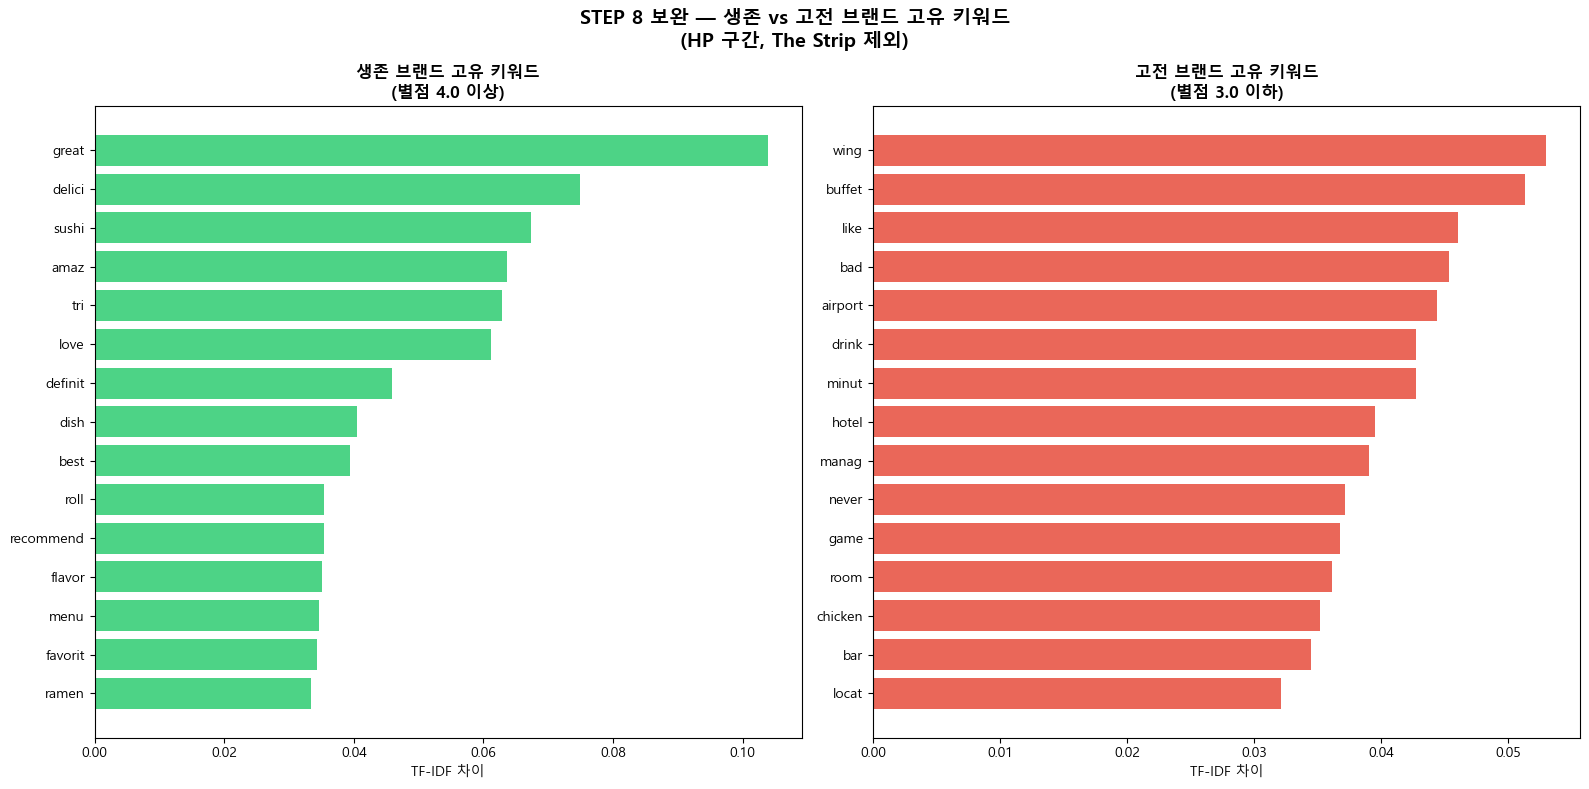

저장 완료: step8_survival_no_strip.png


In [20]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('STEP 8 보완 — 생존 vs 고전 브랜드 고유 키워드\n(HP 구간, The Strip 제외)',
             fontsize=14, fontweight='bold')

top_s_ns = survivor_diff_ns.head(15)
axes[0].barh(top_s_ns.index[::-1], top_s_ns.values[::-1],
             color='#2ecc71', alpha=0.85)
axes[0].set_title('생존 브랜드 고유 키워드\n(별점 4.0 이상)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('TF-IDF 차이')

top_str_ns = struggle_diff_ns.head(15)
axes[1].barh(top_str_ns.index[::-1], top_str_ns.values[::-1],
             color='#e74c3c', alpha=0.85)
axes[1].set_title('고전 브랜드 고유 키워드\n(별점 3.0 이하)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('TF-IDF 차이')

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step8_survival_no_strip.png", dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: step8_survival_no_strip.png")

### STEP 8-5 보완 결과

**분석 대상**
- 생존 브랜드: 429개 / 리뷰 114,265개
- 고전 브랜드: 204개 / 리뷰 17,805개

**생존 브랜드 고유 키워드 (Strip 제외)**:
great, delici, sushi, amaz, love, dish, roll, recommend, flavor, ramen, fresh, noodle, spicy

→ 음식 품질(delici, flavor, fresh) + **아시안 퀴진 전문성(sushi, roll, ramen, noodle)**
   고압력 환경에서 특색있는 전문 음식으로 차별화한 브랜드가 생존한다.

**고전 브랜드 고유 키워드 (Strip 제외)**:
wing, buffet, bad, airport, drink, minut, hotel, manag, never, game, room, waitress

→ 부속 시설 특성(hotel, airport, game, room) + **서비스 실패 신호(bad, never, minut, waitress, manag)**
   Strip 노이즈 제거 후 고전 브랜드의 핵심 문제가 서비스 품질임이 선명하게 드러났다.

---

### Strip 제외 전후 비교

| | Strip 포함 | Strip 제외 |
|---|---|---|
| 고전 브랜드 주요 특성 | 카지노/호텔 부속 시설 | 서비스 실패 + 부속 시설 |
| 새로 드러난 인사이트 | - | bad, never, minut, waitress → 서비스 품질 문제 |

The Strip 상권 노이즈를 제거하면 고전 브랜드의 핵심 문제가
**카지노/호텔 부속 특성**에서 **서비스 품질 실패**로 전환된다.

---

### 핵심 결론

> **고압력(HP) 환경에서 살아남는 독립 브랜드의 두 가지 조건:**
>
> 1. **음식 전문성**: delici, sushi, ramen, noodle, flavor, fresh
>    → 프랜차이즈가 제공하기 어려운 특색있는 전문 음식으로 차별화
>
> 2. **서비스 품질**: recommend, excel, perfect
>    → 부정적 서비스 경험(bad, minut, waitress, never)을 피하고
>    긍정적 경험을 제공하는 것이 생존의 핵심

> **실무 시사점**:
> 프랜차이즈 밀집 지역에서 독립 브랜드가 살아남으려면
> "프랜차이즈가 잘하는 것(빠른 서비스, 표준화)"을 따라하는 것이 아니라
> "프랜차이즈가 못하는 것(전문 음식, 개인화된 서비스 경험)"으로
> 차별화해야 한다.

> **분석 한계**:
> - The Strip 제외 후 고전 브랜드 리뷰(17,805개)가 생존 브랜드(114,265개) 대비
>   적어 키워드 신뢰도 차이가 있을 수 있음
> - Restaurants 카테고리 전체 분석으로 세부 업종 이질성 존재
> - 라스베가스 특유의 카지노/공항 상권 특성이 결과에 영향을 미칠 수 있어
>   타 도시에 대한 일반화에는 한계가 있음

---
## STEP 8-6. HP 구간 회귀분석 — 생존을 결정하는 단어 (OLS + HC3)

STEP 8-2의 TF-IDF 차이 분석은 탐색적 수준에 머문다.
본 분석에서는 HP 구간 브랜드를 대상으로 TF-IDF 단어를 독립변수로 하는
회귀분석을 수행하여 **별점을 통계적으로 유의미하게 결정하는 단어**를 추출한다.

STEP 06b(전체 독립 브랜드 대상)와의 차이:

| 항목 | STEP 06b | STEP 8-6 |
|---|---|---|
| 분석 대상 | 전체 독립 브랜드 3,017개 | HP 구간 생존+고전 894개 |
| 목적 | 일반적 별점 결정 요인 | HP 환경 생존 전략 키워드 |
| 인사이트 | 일반적 패턴 | **처방적 차별화 전략** |

**분석 조건**
- 독립변수: 브랜드별 TF-IDF (min_df=0.05, max_df=0.90, max_features=500)
- 종속변수: 별점 (stars)
- 전처리: log(x+1) + StandardScaler
- 회귀 방법: OLS + HC3 Robust Standard Error
- 통제변수: log(review_count)

### 8-6-1. 데이터 준비

In [21]:
import scipy.sparse as sp
import statsmodels.api as sm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

# HP 구간 생존 + 고전 브랜드
hp_labeled_reg = pd.concat([survivor, struggle], ignore_index=True)

print(f"분석 대상: {len(hp_labeled_reg):,}개")
print(f"  생존: {len(survivor)}개 / 고전: {len(struggle)}개")

분석 대상: 894개
  생존: 567개 / 고전: 327개


### 8-6-2. 브랜드별 TF-IDF 계산

In [23]:
# HP 브랜드별 리뷰 텍스트 합치기
review_hp_reg = review_cleaned.merge(
    hp_labeled_reg[['business_id']],
    on='business_id', how='inner'
)

brand_hp = review_hp_reg.groupby('business_id').agg(
    text_clean=('text_clean', lambda x: ' '.join(x.dropna().astype(str)))
).reset_index()

# stars, review_count는 hp_labeled_reg에서 따로 merge
brand_hp = brand_hp.merge(
    hp_labeled_reg[['business_id', 'stars', 'review_count']],
    on='business_id', how='inner'
)

# 텍스트 없는 브랜드 제거
brand_hp = brand_hp[brand_hp['text_clean'].str.strip() != ''].copy()

print(f"브랜드 수: {len(brand_hp):,}개")
print(f"별점 분포:\n{brand_hp['stars'].describe().round(2)}")

브랜드 수: 894개
별점 분포:
count    894.00
mean       3.64
std        0.83
min        1.00
25%        3.00
50%        4.00
75%        4.00
max        5.00
Name: stars, dtype: float64


In [29]:
# TF-IDF 계산
vectorizer_hp = TfidfVectorizer(
    min_df=0.05,
    max_df=0.90,
    max_features=150 # max_features 줄이기 (894개 관측치 → 150개 단어)
)
tfidf_hp = vectorizer_hp.fit_transform(brand_hp['text_clean'])
terms_hp  = vectorizer_hp.get_feature_names_out()

print(f"TF-IDF 행렬: {tfidf_hp.shape}")
print(f"단어 수: {len(terms_hp)}개")

TF-IDF 행렬: (894, 150)
단어 수: 150개


### 8-6-3. 독립변수 전처리 및 회귀분석

In [30]:
# log(x+1) + StandardScaler
X_hp = np.log1p(tfidf_hp.toarray())
scaler_hp = StandardScaler()
X_hp_scaled = scaler_hp.fit_transform(X_hp)

# 통제변수: log(review_count)
log_review_hp = np.log(brand_hp['review_count'].values + 1).reshape(-1, 1)
X_hp_final = np.hstack([X_hp_scaled, log_review_hp])

feature_names_hp = list(terms_hp) + ['log_review']
X_hp_df = pd.DataFrame(X_hp_final, columns=feature_names_hp)
X_hp_df = sm.add_constant(X_hp_df)

y_hp = brand_hp['stars'].values

# OLS + HC3
model_hp = sm.OLS(y_hp, X_hp_df).fit(cov_type='HC3')

print("=" * 60)
print("HP 구간 OLS + HC3 회귀분석 결과")
print("=" * 60)
print(f"R²        : {model_hp.rsquared:.4f}")
print(f"Adj R²    : {model_hp.rsquared_adj:.4f}")
print(f"F-stat    : {model_hp.fvalue:.4f} (p={model_hp.f_pvalue:.4f})")
print(f"관측치 수 : {int(model_hp.nobs):,}개")
print(f"변수 수   : {model_hp.df_model:.0f}개")

HP 구간 OLS + HC3 회귀분석 결과
R²        : 0.8121
Adj R²    : 0.7739
F-stat    : 23.9402 (p=0.0000)
관측치 수 : 894개
변수 수   : 151개


In [31]:
# 유의미한 단어 추출
results_hp = pd.DataFrame({
    'word': model_hp.params.index,
    'coef': model_hp.params.values,
    'pvalue': model_hp.pvalues.values
})

results_hp = results_hp[
    ~results_hp['word'].isin(['const', 'log_review'])
].copy()

sig_hp = results_hp[results_hp['pvalue'] < 0.05].copy()
sig_hp_pos = sig_hp[sig_hp['coef'] > 0].sort_values('coef', ascending=False)
sig_hp_neg = sig_hp[sig_hp['coef'] < 0].sort_values('coef')

print(f"유의미한 단어 수: {len(sig_hp)}개 (p<0.05)")
print(f"  긍정 방향: {len(sig_hp_pos)}개")
print(f"  부정 방향: {len(sig_hp_neg)}개")

print(f"\n=== HP 구간 별점 상승 단어 (생존 전략 키워드) ===")
print(sig_hp_pos[['word', 'coef', 'pvalue']].head(20).round(4).to_string(index=False))

print(f"\n=== HP 구간 별점 하락 단어 (고전 위험 키워드) ===")
print(sig_hp_neg[['word', 'coef', 'pvalue']].head(20).round(4).to_string(index=False))

유의미한 단어 수: 21개 (p<0.05)
  긍정 방향: 9개
  부정 방향: 12개

=== HP 구간 별점 상승 단어 (생존 전략 키워드) ===
   word   coef  pvalue
   amaz 0.1163  0.0017
 awesom 0.0905  0.0069
definit 0.0889  0.0071
 delici 0.0748  0.0484
   seat 0.0726  0.0213
perfect 0.0598  0.0333
favorit 0.0585  0.0287
    new 0.0550  0.0283
    big 0.0502  0.0494

=== HP 구간 별점 하락 단어 (고전 위험 키워드) ===
   word    coef  pvalue
    bad -0.1066  0.0006
 better -0.0922  0.0004
   away -0.0760  0.0055
 pretti -0.0756  0.0074
 buffet -0.0723  0.0043
  minut -0.0710  0.0247
   hour -0.0706  0.0408
    egg -0.0688  0.0435
  manag -0.0623  0.0452
   noth -0.0606  0.0240
   serv -0.0599  0.0278
husband -0.0547  0.0322


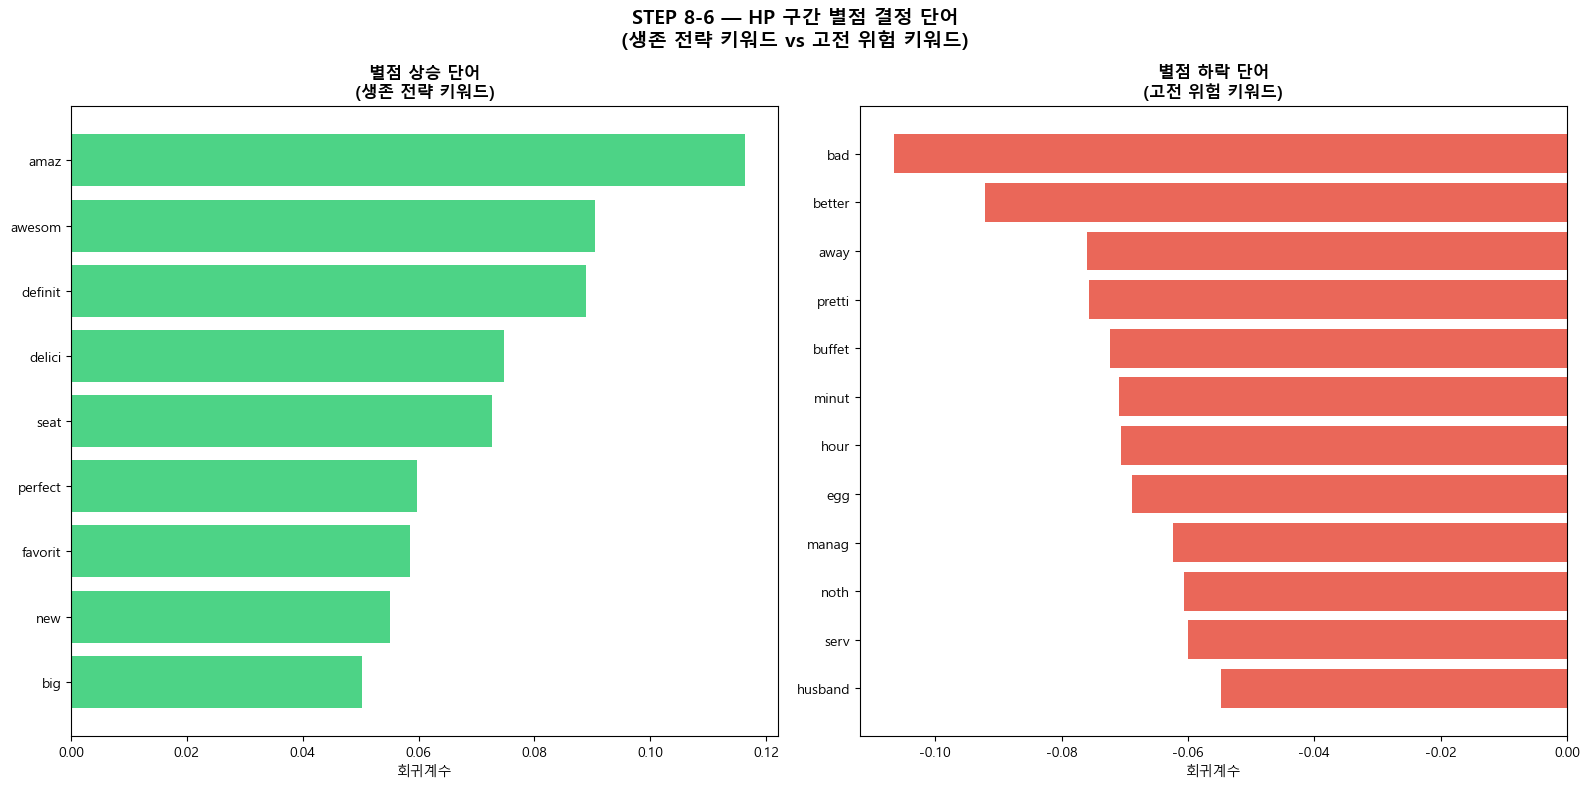

저장 완료: step8_6_hp_regression.png


In [32]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('STEP 8-6 — HP 구간 별점 결정 단어\n(생존 전략 키워드 vs 고전 위험 키워드)',
             fontsize=14, fontweight='bold')

top_pos_hp = sig_hp_pos.head(15)
axes[0].barh(top_pos_hp['word'][::-1], top_pos_hp['coef'][::-1],
             color='#2ecc71', alpha=0.85)
axes[0].set_title('별점 상승 단어\n(생존 전략 키워드)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('회귀계수')

top_neg_hp = sig_hp_neg.head(15)
axes[1].barh(top_neg_hp['word'][::-1], top_neg_hp['coef'][::-1],
             color='#e74c3c', alpha=0.85)
axes[1].set_title('별점 하락 단어\n(고전 위험 키워드)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('회귀계수')

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step8_6_hp_regression.png", dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: step8_6_hp_regression.png")

---
## STEP 8-7. STEP 06b 유의미 단어로 생존/고전 교차 검증

STEP 06b에서 별점에 유의미한 영향을 미치는 것으로 확인된 단어들이
HP 구간 생존/고전 브랜드에서도 동일한 패턴을 보이는지 검증한다.

두 분석이 일관된 결론을 지지하면 분석의 신뢰도가 높아진다.

**검증 방법**: Mann-Whitney U 검정
- 귀무가설: 생존/고전 브랜드 간 해당 단어 TF-IDF 점수 분포 차이 없음
- 대립가설: 분포 차이 있음 (p < 0.05)

In [33]:
from scipy.stats import mannwhitneyu

# STEP 06b 유의미 단어 (긍정/부정 각 상위)
pos_words = ['awesom', 'amaz', 'delici', 'favorit', 'excel', 'qualiti', 'enjoy', 'worth']
neg_words = ['worst', 'rude', 'slow', 'horribl', 'terribl', 'noth', 'bad', 'pay']

key_words = {'긍정(생존 예측)': pos_words, '부정(고전 예측)': neg_words}

# HP 구간 생존/고전 인덱스
survivor_mask = brand_hp['business_id'].isin(survivor['business_id'])
struggle_mask  = brand_hp['business_id'].isin(struggle['business_id'])

terms_hp_list = list(terms_hp)

print("=" * 65)
print("STEP 06b 유의미 단어 × HP 구간 생존/고전 Mann-Whitney U 검정")
print("=" * 65)

for direction, words in key_words.items():
    print(f"\n[{direction}]")
    print(f"{'단어':>12} | {'생존 평균':>10} | {'고전 평균':>10} | {'p-value':>10} | 유의미")
    print("-" * 65)
    for word in words:
        if word not in terms_hp_list:
            print(f"{word:>12} | {'단어 없음':>35}")
            continue
        idx = terms_hp_list.index(word)
        s_scores = tfidf_hp[survivor_mask.values, idx].toarray().flatten()
        g_scores  = tfidf_hp[struggle_mask.values, idx].toarray().flatten()
        stat, p = mannwhitneyu(s_scores, g_scores, alternative='two-sided')
        sig = '✅' if p < 0.05 else '❌'
        print(f"{word:>12} | {s_scores.mean():>10.4f} | {g_scores.mean():>10.4f} | {p:>10.4f} | {sig}")

STEP 06b 유의미 단어 × HP 구간 생존/고전 Mann-Whitney U 검정

[긍정(생존 예측)]
          단어 |      생존 평균 |      고전 평균 |    p-value | 유의미
-----------------------------------------------------------------
      awesom |     0.0519 |     0.0234 |     0.0000 | ✅
        amaz |     0.0936 |     0.0288 |     0.0000 | ✅
      delici |     0.1152 |     0.0403 |     0.0000 | ✅
     favorit |     0.0555 |     0.0233 |     0.0000 | ✅
       excel |     0.0481 |     0.0179 |     0.0000 | ✅
     qualiti |     0.0382 |     0.0351 |     0.0061 | ✅
       enjoy |     0.0544 |     0.0340 |     0.0000 | ✅
       worth |     0.0382 |     0.0315 |     0.0000 | ✅

[부정(고전 예측)]
          단어 |      생존 평균 |      고전 평균 |    p-value | 유의미
-----------------------------------------------------------------
       worst |                               단어 없음
        rude |                               단어 없음
        slow |                               단어 없음
     horribl |                               단어 없음
     terribl |            

### 교차 검증 결과 해석

**긍정 단어 — 8개 전부 유의미 (p<0.05)**

STEP 06b에서 별점을 높이는 것으로 확인된 단어들이
HP 구간 생존 브랜드에서 고전 브랜드 대비 유의미하게 높게 나타났다.

| 방향 | 검증 결과 | 해석 |
|---|---|---|
| 긍정 단어 (awesom, amaz, delici 등) | 8/8 유의미  | 생존 브랜드에서 일관되게 높음 |
| 부정 단어 (noth, bad, pay) | 3/8 유의미  | 고전 브랜드에서 일관되게 높음 |
| 부정 단어 (worst, rude, slow 등) | 단어 없음 | min_df 필터로 제외 (희귀 단어) |

> worst, rude, slow 등 극단적 부정어가 필터에서 제외된 것은
> 이 단어들이 특정 고전 브랜드에만 집중 등장하고
> HP 구간 전체에 고르게 분포하지 않기 때문이다.
> 즉, 고전 브랜드 일부는 극단적 서비스 실패를 경험하지만
> 모든 고전 브랜드의 공통 특성은 아님을 시사한다.

**STEP 06a, 06b, 08 종합:**
> 세 분석이 독립적으로 같은 결론을 지지한다.
> 프랜차이즈 밀집 환경에서 독립 브랜드가 살아남으려면
> 음식 품질(delici, amaz)과 긍정적 경험(awesom, favorit)을 제공해야 하며,
> 서비스 불만(bad, noth, pay)을 최소화하는 것이 핵심이다.

---
## STEP 8-8. FPI 지도 시각화 — 창업자 입지 선정 도구

Las Vegas 독립 브랜드의 FPI 분포를 지도에 시각화한다.
창업자가 상권 진입 전 경쟁 압력 수준을 사전 파악할 수 있는 실무 활용 도구다.

- **색깔**: FPI 수치 (초록 → 낮은 압력 / 빨강 → 높은 압력)
- **크기**: 리뷰수 (매장 규모)
- **hover**: 업체명, 별점, FPI, 구간

In [33]:
import plotly.express as px

indie_map = indie_groups.copy()
indie_map['fpi_group'] = indie_map['fpi_group'].fillna('NP')

# FPI 구간 한글 라벨
group_label = {'NP': '무풍지대 (NP)', 'LP': '저압력 (LP)', 'HP': '고압력 (HP)'}
indie_map['구간'] = indie_map['fpi_group'].map(group_label)

fig = px.scatter_mapbox(
    indie_map,
    lat='latitude',
    lon='longitude',
    color='fpi_300m',
    color_continuous_scale='RdYlGn_r',
    size='review_count',
    size_max=20,
    hover_name='name',
    hover_data={
        'stars': True,
        'fpi_300m': ':.3f',
        '구간': True,
        'review_count': True,
        'neighborhood': True,
        'latitude': False,
        'longitude': False
    },
    zoom=11,
    height=700,
    title='Las Vegas 독립 브랜드 FPI 분포 지도 (fpi_300m 기준)'
)
fig.update_layout(
    mapbox_style='open-street-map',
    margin={'r': 0, 't': 50, 'l': 0, 'b': 0},
    coloraxis_colorbar=dict(
        title='FPI (경쟁압력)',
        tickvals=[0, 2, 4, 6, 8],
        ticktext=['0 (무풍)', '2', '4', '6', '8↑ (고압력)']
    )
)
fig.write_html(f"{PATH_to_save}/fpi_map.html")
print("저장 완료: fpi_map.html")
fig.show()

저장 완료: fpi_map.html


In [34]:
# FPI 구간별 색깔 지도 (NP/LP/HP 구분)
color_map = {
    '무풍지대 (NP)': '#4a90e2',
    '저압력 (LP)':   '#f5a623',
    '고압력 (HP)':   '#e65100'
}

fig2 = px.scatter_mapbox(
    indie_map,
    lat='latitude',
    lon='longitude',
    color='구간',
    color_discrete_map=color_map,
    size='review_count',
    size_max=20,
    hover_name='name',
    hover_data={
        'stars': True,
        'fpi_300m': ':.3f',
        '구간': True,
        'review_count': True,
        'neighborhood': True,
        'latitude': False,
        'longitude': False
    },
    zoom=11,
    height=700,
    title='Las Vegas 독립 브랜드 FPI 구간 분포 지도'
)
fig2.update_layout(
    mapbox_style='open-street-map',
    margin={'r': 0, 't': 50, 'l': 0, 'b': 0}
)
fig2.write_html(f"{PATH_to_save}/fpi_map_group.html")
print("저장 완료: fpi_map_group.html")
fig2.show()

저장 완료: fpi_map_group.html


---
## FPI 지도 결과 해석

### 공간적 패턴 관찰

**① Strip 중심부 = 프랜차이즈 경쟁 과밀 구역**

Paradise, The Strip 인근 주요 관광 동선을 따라 FPI가 압도적으로 높게 나타난다.
이는 단순히 프랜차이즈 수가 많다는 의미를 넘어, 접근성 높은 관광 상권에
체인 브랜드 선호 소비층이 집중되어 있음을 의미한다.

> 독립 브랜드 입장에서 Strip 상권은 매출 잠재력은 크지만
> 가격·브랜드·광고 경쟁 부담이 극심한 레드오션이다.
> 이 지역에서 생존하려면 차별화된 컨셉, 특정 문화/경험 제공,
> niche targeting 전략이 필수적이다.

---

**② 도심 외곽 = 저압력 분산형 구조**

Summerlin, Spring Valley 등 서쪽·남쪽 주거지역으로 갈수록
LP/NP 비중이 높아지며 프랜차이즈 공백 지역이 다수 존재한다.

> 외곽 주거 상권은 관광객보다 로컬 수요 중심으로,
> 임대료 부담이 낮고 단골 기반 운영이 가능하여
> 독립 브랜드 생존 가능성이 상대적으로 높다.
> 커뮤니티 기반 매장, 지역 특화 브랜드에 유리한 환경이다.

---

**③ 프랜차이즈 경쟁은 면(area)이 아닌 교통축(linear corridor) 중심**

구간화 지도에서 HP가 주요 대로변·교차로를 따라 선형으로 이어지는 패턴이 나타난다.
이는 프랜차이즈 확장이 도시 전체를 균일하게 커버하는 것이 아니라
접근성 높은 교통축 중심으로 집중되고 있음을 시사한다.

---

**④ 무풍지대(NP)는 완전히 사라지지 않는다**

프랜차이즈가 도시 전체를 균일하게 장악했다면 NP는 거의 존재하지 않아야 한다.
그러나 외곽은 물론 일부 중심부에도 NP가 곳곳에 존재한다.

> 이는 프랜차이즈 확장이 도시를 완전히 커버하지 못하며,
> 독립 브랜드에게 niche opportunity, 지역 특화 시장,
> 상권 공백이 여전히 존재한다는 시사점을 준다.

---

### 보고서용 결론 문장

> Las Vegas의 독립 브랜드는 관광 중심 상권에서 높은 프랜차이즈 경쟁압력(FPI)에
> 노출되어 있으며, 특히 Strip 축을 따라 경쟁이 집중되는 공간적 패턴이 나타났다.
> 반면 외곽 주거지역에서는 저압력 또는 무풍지대가 다수 확인되어,
> 독립 브랜드의 생존 가능성이 상대적으로 높은 지역적 틈새시장(niche market)이
> 존재함을 확인하였다. 경쟁압력은 단순 면적 기반이 아니라
> 주요 교통축과 상권 네트워크를 따라 선형적으로 형성되는 경향을 보였다.

---

### 입지 선정 가이드

| 상권 유형 | FPI 수준 | 특성 | 추천 전략 |
|---|---|---|---|
| Strip/Paradise | 고압력 (4↑) | 관광객 중심, 레드오션 | 경험형 컨셉, SNS 바이럴, 관광객 특화 |
| 주요 대로변 | 중간 (1~3) | 교통축 상권 | 정통 요리 전문성, 서비스 차별화 |
| 외곽 주거지 | 저압력~무풍 (0~1) | 로컬 수요 중심 | 단골 기반, 커뮤니티형, 에스닉 전문점 |